## Notebook 04: Rescue Classification (Extension)

Building on the DE results from notebook 02, this is a test whether Anakinra treatment moves gene expression back toward the unedited baseline (RNP_NEG), for genes significantly affected by gene editing (GE vs RNP_NEG).

Two measures were useds: 
- a continuous rescue percentage per gene
- a formal categorical classification (full/partial/persistent rescue) based on significance testing

Given the weak individual-gene signal found for GE_ANAK_vs_GE in notebooks 02-03, categorical classification is expected to show mostly "persistent" genes, while the continuous percentage should reveal a more graded pattern.

In [1]:
import pandas as pd
from hspc_response.io import load_config, resolve_path
from hspc_response.rescue import compute_rescue_percent, classify_rescue, classify_rescue
from hspc_response.plotting import plot_rescue_distribution

In [2]:
config = load_config()
tables_dir = resolve_path(config["paths"]["tables_dir"])

# Load all six DE result tables (2 timepoints x 3 contrasts)
results = {}
for timepoint in config["design"]["timepoints"]:
    for contrast_cfg in config["design"]["contrasts"]:
        name = contrast_cfg["name"]
        path = tables_dir / f"{timepoint}_{name}.csv"
        results[(timepoint, name)] = pd.read_csv(path, index_col=0)

padj_threshold = config["thresholds"]["padj"]

## Compute rescue percentage (24h)

In [3]:
# Genes significant in GE_vs_RNP_NEG at 24h (the genes actually affected by editing)
sig_genes_24h = results[("24h", "GE_vs_RNP_NEG")][
    results[("24h", "GE_vs_RNP_NEG")]["padj"] < padj_threshold
].index


# Compute rescue percentage for those genes, using GE and GE_ANAK values. They are both measured relative to the same RNP_NEG baseline
rescue_pct_24h = compute_rescue_percent(
    results[("24h", "GE_vs_RNP_NEG")].loc[sig_genes_24h],
    results[("24h", "GE_ANAK_vs_RNP_NEG")],
)

print(f"Computed rescue % for {len(rescue_pct_24h)} genes significant in GE_vs_RNP_NEG at 24h")
print(rescue_pct_24h.describe())

Computed rescue % for 560 genes significant in GE_vs_RNP_NEG at 24h
count    560.000000
mean      -1.167633
std       17.419701
min      -51.304105
25%      -11.896535
50%       -1.823848
75%       10.264122
max       77.847037
Name: log2FoldChange, dtype: float64


## Compute rescue percentage (96h)

In [4]:
# Genes significant in GE_vs_RNP_NEG at 96h (the genes actually affected by editing)
sig_genes_96h = results[("96h", "GE_vs_RNP_NEG")][
    results[("96h", "GE_vs_RNP_NEG")]["padj"] < padj_threshold
].index

# Compute rescue percentage for those genes, using GE and GE_ANAK values. They are both measured relative to the same RNP_NEG baseline
rescue_pct_96h = compute_rescue_percent(
    results[("96h", "GE_vs_RNP_NEG")].loc[sig_genes_96h],
    results[("96h", "GE_ANAK_vs_RNP_NEG")],
)

print(f"Computed rescue % for {len(rescue_pct_96h)} genes significant in GE_vs_RNP_NEG at 96h")
print(rescue_pct_96h.describe())

Computed rescue % for 39 genes significant in GE_vs_RNP_NEG at 96h
count    39.000000
mean     12.109655
std      20.860985
min     -24.117662
25%      -2.111523
50%       8.743089
75%      21.283692
max      60.542773
Name: log2FoldChange, dtype: float64


### Note on 24h rescue percentage after matching the paper's significance threshold

After removing the log2FC filter to match Conti et al.'s exact significance criterion (padj<0.05 only), the 24h GE-significant gene set grew from 204 to 560 genes, and the median rescue percentage shifted from +0.25% to -1.8%. Both values are close to zero and consistent with the same core finding, which is that there's no meaningful net rescue at 24h, unlike the clear positive signal at 96h (median 8.7%, unchanged by this threshold choice since 96h's significant gene count did not change). The larger, noisier 24h gene set includes more genes with small GE effect sizes, which are less numerically stable in the rescue percentage ratio.


In [ ]:
# Classify each gene's rescue status (full/partial/persistent) at 24h, using significance tests of GE_ANAK_vs_GE and GE_ANAK_vs_RNP_NEG
rescue_class_24h = classify_rescue(
    results[("24h", "GE_ANAK_vs_GE")],
    results[("24h", "GE_ANAK_vs_RNP_NEG")],
    alpha=config["thresholds"]["rescue_alpha"],
)
rescue_class_24h_sig = rescue_class_24h.loc[rescue_class_24h.index.intersection(sig_genes_24h)]

# Same classification at 96h
rescue_class_96h = classify_rescue(
    results[("96h", "GE_ANAK_vs_GE")],
    results[("96h", "GE_ANAK_vs_RNP_NEG")],
    alpha=config["thresholds"]["rescue_alpha"],
)
rescue_class_96h_sig = rescue_class_96h.loc[rescue_class_96h.index.intersection(sig_genes_96h)]

print("24h classification counts (among GE-significant genes):")
print(rescue_class_24h_sig.value_counts())
print("\n96h classification counts (among GE-significant genes):")
print(rescue_class_96h_sig.value_counts())

24h classification counts (among GE-significant genes):
persistent    560
Name: count, dtype: int64

96h classification counts (among GE-significant genes):
persistent    39
Name: count, dtype: int64


## Interpretation: categorical classification vs. continuous rescue score

The formal categorical classification places 100% of GE-significant genes into "persistent" at both timepoints. This is a direct consequence of zero genes reaching individual significance in the GE_ANAK_vs_GE contrast (consistent with notebooks 02-03). This is not a null result about rescue itself. It reflects a genuine limitation of significance-based classification at this sample size (n=3 per group), where real, modest, coordinated shifts do not individually clear a strict statistical threshold.

This directly motivates the continuous rescue percentage as the primary tool for characterizing rescue in this analysis. It reveals a real, quantifiable, timepoint-dependent pattern (median -1.8% rescue at 24h vs. 8.7% at 96h) that the categorical method cannot detect at this sample size, by design. Both results are reported here together deliberately, since the contrast between them illustrates an important methodological point about power limitations with small n, rather than being reported in isolation.

## Visualize rescue percentage distributions

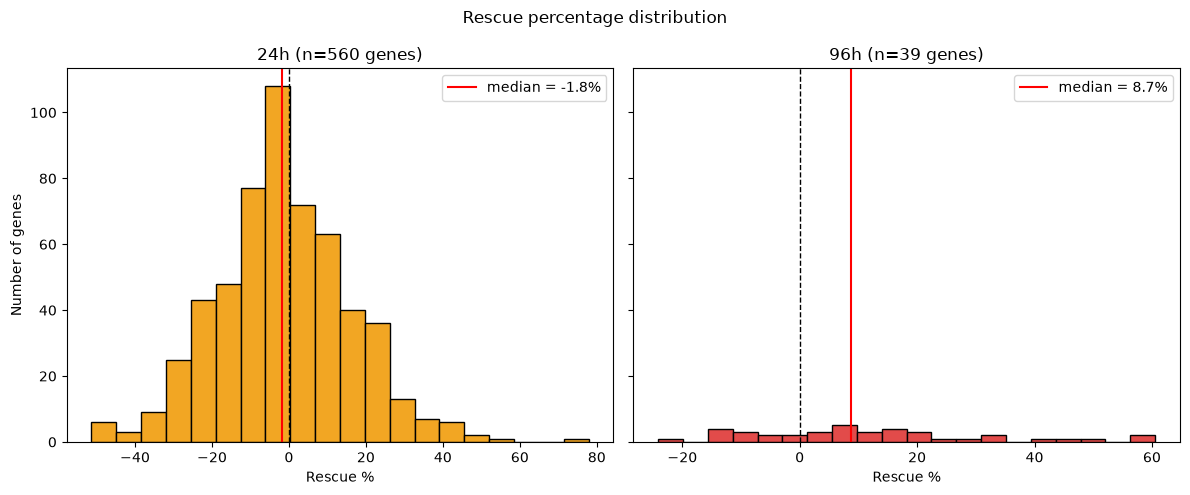

In [6]:
# Visualize both timepoints' rescue percentage distributions side by side
plot_rescue_distribution(
    {"24h": rescue_pct_24h, "96h": rescue_pct_96h},
    save_path=resolve_path("results/figures/rescue_percent_distribution.png"),
)